<>:88: SyntaxWarning: invalid escape sequence '\l'
<>:88: SyntaxWarning: invalid escape sequence '\l'
/var/folders/1r/vjpdk3yx7bx3plgph73_bjlh0000gn/T/ipykernel_69527/2343789904.py:88: SyntaxWarning: invalid escape sequence '\l'
  The theorem is of type \lesssim, so we keep a prefactor.


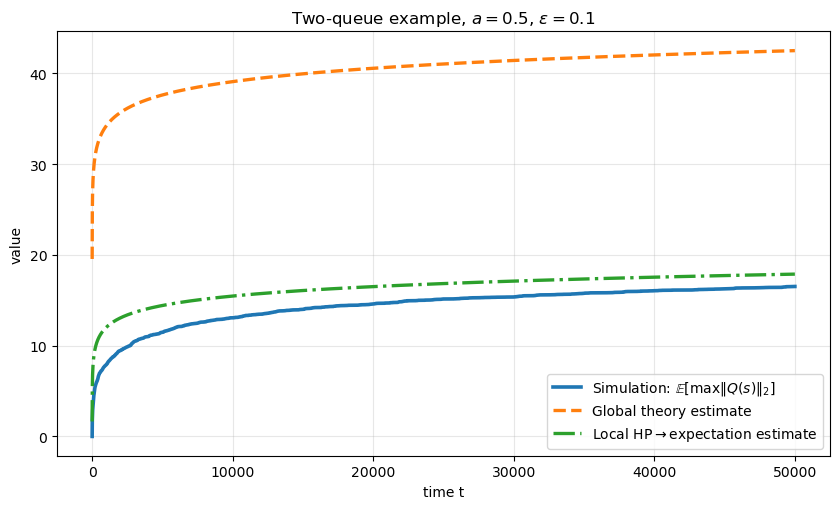

In [37]:
import numpy as np
import matplotlib.pyplot as plt


def simulate_two_queue_maxweight(a=0.1, eps=0.1, T=5000, seed=None):
    """
    Two-queue example:
        S = {(1,0), (0,a)}

    MaxWeight rule:
        choose (1,0) if q1 >= a*q2
        choose (0,a) otherwise

    Arrivals:
        A1 ~ Bernoulli((1-eps)/2)
        A2 ~ Bernoulli(a*(1-eps)/2)

    Then:
        E[A1] + (1/a) E[A2] = 1 - eps

    Returns
    -------
    norm2_path      : ||Q(t)||_2, length T+1
    peak_norm2_path : max_{0<=s<=t} ||Q(s)||_2, length T+1
    """
    rng = np.random.default_rng(seed)

    p1 = 0.5 * (1.0 - eps)
    p2 = 0.5 * a * (1.0 - eps)

    q1 = 0.0
    q2 = 0.0

    norm2_path = np.zeros(T + 1, dtype=float)
    norm2_path[0] = np.sqrt(q1**2 + q2**2)

    for t in range(T):
        # MaxWeight action
        if q1 >= a * q2:
            s1, s2 = 1.0, 0.0
        else:
            s1, s2 = 0.0, a

        # arrivals
        A1 = rng.binomial(1, p1)
        A2 = rng.binomial(1, p2)

        # queue update
        q1 = max(q1 - min(q1, s1), 0.0) + A1
        q2 = max(q2 - min(q2, s2), 0.0) + A2

        norm2_path[t + 1] = np.sqrt(q1**2 + q2**2)

    peak_norm2_path = np.maximum.accumulate(norm2_path)
    return norm2_path, peak_norm2_path


def estimate_expected_peak_norm2(a=0.1, eps=0.1, T=5000, num_runs=1000, base_seed=0):
    """
    Monte Carlo estimate of
        E[max_{s<=t} ||Q(s)||_2]
    """
    all_peak = np.zeros((num_runs, T + 1), dtype=float)

    for k in range(num_runs):
        _, peak_norm2_path = simulate_two_queue_maxweight(
            a=a,
            eps=eps,
            T=T,
            seed=base_seed + k,
        )
        all_peak[k, :] = peak_norm2_path

    return all_peak.mean(axis=0)


def global_corollary_bound(t_grid, a=0.1, eps=0.1, prefactor=1.0):
    """
    Global corollary-style expected peak bound:
        E[Peak_t] esssim (A_max/eps) log(t+1)
                         + (A_max + S_max)^2 / (eps * alpha_2)

    For this example:
        A_max = sqrt(2)
        S_max = 1
        alpha_2 = a / sqrt(1 + a^2)

    The theorem is of type \lesssim, so we keep a prefactor.
    """
    t_grid = np.asarray(t_grid, dtype=float)

    A_max = np.sqrt(2.0)
    S_max = 1.0
    alpha_2 = a / np.sqrt(1.0 + a**2)

    return prefactor * (
        (A_max / eps) * np.log(t_grid + 1.0)
        + ((A_max + S_max) ** 2) / (eps * alpha_2)
    )


def local_hp_to_expectation_curve(t_grid, eps=0.1, prefactor=1.0):
    """
    Expectation-scale curve suggested by the local high-probability proposition.

    From:
        P(Peak_T esssim 1 + (1/eps) log((T+1)/delta)) >= 1-delta

    one gets an expectation bound of the same order:
        E[Peak_T] esssim 1 + (1/eps)(1 + log(T+1))

    This curve is uniform in a.
    """
    t_grid = np.asarray(t_grid, dtype=float)
    return prefactor * (1.0 + (1.0 / eps) * (1.0 + np.log(t_grid + 1.0)))


def plot_three_lines(
    a=0.1,
    eps=0.1,
    T=5000,
    num_runs=2000,
    base_seed=0,
    global_prefactor=1.0,
    local_prefactor=1.0,
):
    """
    Plot one figure with exactly three curves:
      1) simulation
      2) global theory estimate
      3) local HP-to-expectation estimate
    """
    t_grid = np.arange(T + 1)

    sim_curve = estimate_expected_peak_norm2(
        a=a,
        eps=eps,
        T=T,
        num_runs=num_runs,
        base_seed=base_seed,
    )

    global_curve = global_corollary_bound(
        t_grid=t_grid,
        a=a,
        eps=eps,
        prefactor=global_prefactor,
    )

    local_curve = local_hp_to_expectation_curve(
        t_grid=t_grid,
        eps=eps,
        prefactor=local_prefactor,
    )

    plt.figure(figsize=(8.5, 5.2))
    plt.plot(
        t_grid,
        sim_curve,
        linewidth=2.6,
        label=r"Simulation: $\mathbb{E}[\max\|Q(s)\|_2]$"
    )
    plt.plot(
        t_grid,
        global_curve,
        "--",
        linewidth=2.4,
        label=r"Global theory estimate"
    )
    plt.plot(
        t_grid,
        local_curve,
        "-.",
        linewidth=2.4,
        label=r"Local HP$\to$expectation estimate"
    )

    plt.xlabel("time t")
    plt.ylabel("value")
    plt.title(fr"Two-queue example, $a={a}$, $\epsilon={eps}$")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# Example run
# =========================
plot_three_lines(
    a=0.5,
    eps=0.1,
    T=50000,
    num_runs=200,
    base_seed=123,
    global_prefactor=0.15,
    local_prefactor=0.15,
)

<>:87: SyntaxWarning: invalid escape sequence '\l'
<>:114: SyntaxWarning: invalid escape sequence '\l'
<>:87: SyntaxWarning: invalid escape sequence '\l'
<>:114: SyntaxWarning: invalid escape sequence '\l'
/var/folders/1r/vjpdk3yx7bx3plgph73_bjlh0000gn/T/ipykernel_69527/2716953151.py:87: SyntaxWarning: invalid escape sequence '\l'
  E[Peak_t] \lesssim (A_max/eps) log(t+1)
/var/folders/1r/vjpdk3yx7bx3plgph73_bjlh0000gn/T/ipykernel_69527/2716953151.py:114: SyntaxWarning: invalid escape sequence '\l'
  P(Peak_T \lesssim 1 + (1/eps) log((T+1)/delta)) >= 1-delta


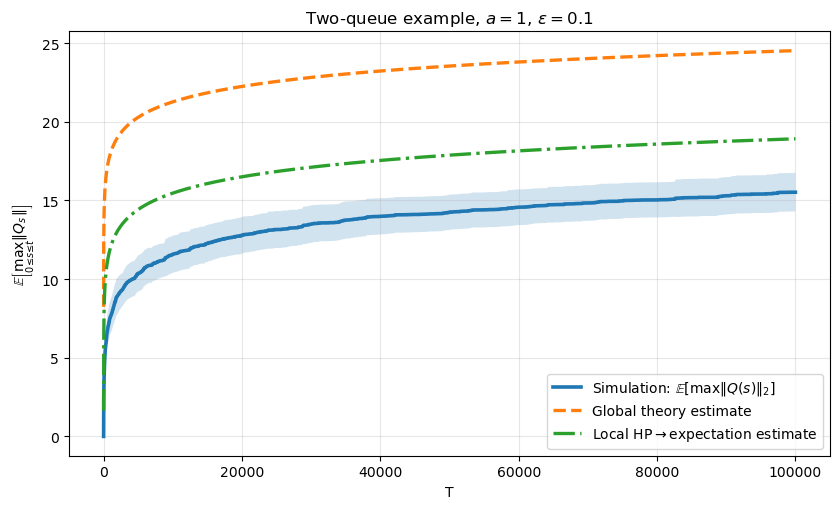

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def simulate_two_queue_maxweight(a=0.1, eps=0.1, T=5000, seed=None):
    """
    Two-queue example:
        S = {(1,0), (0,a)}

    MaxWeight rule:
        choose (1,0) if q1 >= a*q2
        choose (0,a) otherwise

    Arrivals:
        A1 ~ Bernoulli((1-eps)/2)
        A2 ~ Bernoulli(a*(1-eps)/2)

    Then:
        E[A1] + (1/a) E[A2] = 1 - eps

    Returns
    -------
    norm2_path      : ||Q(t)||_2, length T+1
    peak_norm2_path : max_{0<=s<=t} ||Q(s)||_2, length T+1
    """
    rng = np.random.default_rng(seed)

    p1 = 0.5 * (1.0 - eps)
    p2 = 0.5 * a * (1.0 - eps)

    q1 = 0.0
    q2 = 0.0

    norm2_path = np.zeros(T + 1, dtype=float)
    norm2_path[0] = np.sqrt(q1**2 + q2**2)

    for t in range(T):
        # MaxWeight action
        if q1 >= a * q2:
            s1, s2 = 1.0, 0.0
        else:
            s1, s2 = 0.0, a

        # arrivals
        A1 = rng.binomial(1, p1)
        A2 = rng.binomial(1, p2)

        # queue update
        q1 = max(q1 - min(q1, s1), 0.0) + A1
        q2 = max(q2 - min(q2, s2), 0.0) + A2

        norm2_path[t + 1] = np.sqrt(q1**2 + q2**2)

    peak_norm2_path = np.maximum.accumulate(norm2_path)
    return norm2_path, peak_norm2_path


def estimate_expected_peak_norm2(a=0.1, eps=0.1, T=5000, num_runs=1000, base_seed=0):
    """
    Monte Carlo estimate of
        E[max_{s<=t} ||Q(s)||_2]

    Returns
    -------
    mean_peak : shape (T+1,)
    std_peak  : shape (T+1,)
    """
    all_peak = np.zeros((num_runs, T + 1), dtype=float)

    for k in range(num_runs):
        _, peak_norm2_path = simulate_two_queue_maxweight(
            a=a,
            eps=eps,
            T=T,
            seed=base_seed + k,
        )
        all_peak[k, :] = peak_norm2_path

    mean_peak = all_peak.mean(axis=0)
    std_peak = all_peak.std(axis=0, ddof=1) if num_runs > 1 else np.zeros(T + 1)
    return mean_peak, std_peak


def global_corollary_bound(t_grid, a=0.1, eps=0.1, prefactor=1.0):
    """
    Global corollary-style expected peak bound:
        E[Peak_t] \lesssim (A_max/eps) log(t+1)
                         + (A_max + S_max)^2 / (eps * alpha_2)

    For this example:
        A_max = sqrt(2)
        S_max = 1
        alpha_2 = a / sqrt(1 + a^2)

    The theorem is of type \lesssim, so we keep a prefactor.
    """
    t_grid = np.asarray(t_grid, dtype=float)

    A_max = np.sqrt(2.0)
    S_max = 1.0
    alpha_2 = a / np.sqrt(1.0 + a**2)

    return prefactor * (
        (A_max / eps) * np.log(t_grid + 1.0)
        + ((A_max + S_max) ** 2) / (eps * alpha_2)
    )


def local_hp_to_expectation_curve(t_grid, eps=0.1, prefactor=1.0):
    """
    Expectation-scale curve suggested by the local high-probability proposition.

    From:
        P(Peak_T \lesssim 1 + (1/eps) log((T+1)/delta)) >= 1-delta

    one gets an expectation bound of the same order:
        E[Peak_T] \lesssim 1 + (1/eps)(1 + log(T+1))

    This curve is uniform in a.
    """
    t_grid = np.asarray(t_grid, dtype=float)
    return prefactor * (1.0 + (1.0 / eps) * (1.0 + np.log(t_grid + 1.0)))


def plot_three_lines(
    a=0.1,
    eps=0.1,
    T=5000,
    num_runs=2000,
    base_seed=0,
    global_prefactor=1.0,
    local_prefactor=1.0,
    show_std=True,
    std_scale=1.0,
):
    """
    Plot one figure with exactly three curves:
      1) simulation mean
      2) global theory estimate
      3) local HP-to-expectation estimate

    Optionally add std band around simulation:
      mean ± std_scale * std
    """
    t_grid = np.arange(T + 1)

    sim_mean, sim_std = estimate_expected_peak_norm2(
        a=a,
        eps=eps,
        T=T,
        num_runs=num_runs,
        base_seed=base_seed,
    )

    global_curve = global_corollary_bound(
        t_grid=t_grid,
        a=a,
        eps=eps,
        prefactor=global_prefactor,
    )

    local_curve = local_hp_to_expectation_curve(
        t_grid=t_grid,
        eps=eps,
        prefactor=local_prefactor,
    )

    plt.figure(figsize=(8.5, 5.2))

    if show_std:
        lower = np.maximum(sim_mean - std_scale * sim_std, 0.0)
        upper = sim_mean + std_scale * sim_std
        plt.fill_between(
            t_grid,
            lower,
            upper,
            alpha=0.20,
            #label=fr"Simulation $\pm {std_scale}\,$std"
        )

    plt.plot(
        t_grid,
        sim_mean,
        linewidth=2.6,
        label=r"Simulation: $\mathbb{E}[\max\|Q(s)\|_2]$"
    )
    plt.plot(
        t_grid,
        global_curve,
        "--",
        linewidth=2.4,
        label=r"Global prediction"
    )
    plt.plot(
        t_grid,
        local_curve,
        "-.",
        linewidth=2.4,
        label=r"Local prediction"
    )

    plt.xlabel("T")
    plt.ylabel(rf"$\mathbb{{E}}\left[\max_{{0\leq s\leq t}}\|Q_s\| \right]$")
    plt.title(fr"Two-queue example, $a={a}$")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# Example run
# =========================
plot_three_lines(
    a=1,
    eps=0.1,
    T=100000,
    num_runs=200,
    base_seed=123,
    global_prefactor=0.1,
    local_prefactor=0.15,
    show_std=True,
    std_scale=0.5,   # 画 mean ± 1 std
)

<>:84: SyntaxWarning: invalid escape sequence '\l'
<>:102: SyntaxWarning: invalid escape sequence '\l'
<>:84: SyntaxWarning: invalid escape sequence '\l'
<>:102: SyntaxWarning: invalid escape sequence '\l'
/var/folders/1r/vjpdk3yx7bx3plgph73_bjlh0000gn/T/ipykernel_70538/2325209669.py:84: SyntaxWarning: invalid escape sequence '\l'
  E[Peak_t] \lesssim (A_max/eps) log(t+1)
/var/folders/1r/vjpdk3yx7bx3plgph73_bjlh0000gn/T/ipykernel_70538/2325209669.py:102: SyntaxWarning: invalid escape sequence '\l'
  E[Peak_T] \lesssim 1 + (1/eps)(1 + log(T+1))


Saved figure to two_queue_example.pdf


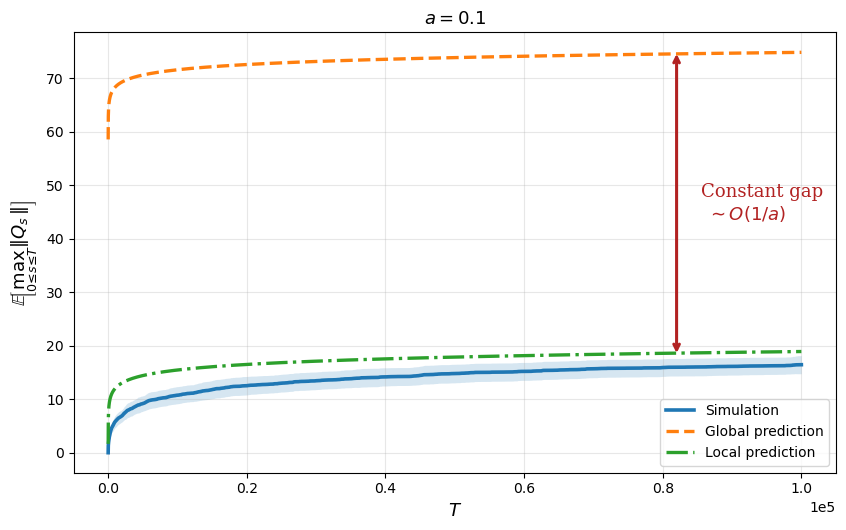

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

#mpl.rcParams["mathtext.fontset"] = "cm"
def simulate_two_queue_maxweight(a=0.1, eps=0.1, T=5000, seed=None):
    """
    Two-queue example:
        S = {(1,0), (0,a)}

    MaxWeight rule:
        choose (1,0) if q1 >= a*q2
        choose (0,a) otherwise

    Arrivals:
        A1 ~ Bernoulli((1-eps)/2)
        A2 ~ Bernoulli(a*(1-eps)/2)

    Then:
        E[A1] + (1/a) E[A2] = 1 - eps

    Returns
    -------
    norm2_path      : ||Q(t)||_2, length T+1
    peak_norm2_path : max_{0<=s<=t} ||Q(s)||_2, length T+1
    """
    rng = np.random.default_rng(seed)

    p1 = 0.5 * (1.0 - eps)
    p2 = 0.5 * a * (1.0 - eps)

    q1 = 0.0
    q2 = 0.0

    norm2_path = np.zeros(T + 1, dtype=float)
    norm2_path[0] = np.sqrt(q1**2 + q2**2)

    for t in range(T):
        if q1 >= a * q2:
            s1, s2 = 1.0, 0.0
        else:
            s1, s2 = 0.0, a

        A1 = rng.binomial(1, p1)
        A2 = rng.binomial(1, p2)

        q1 = max(q1 - min(q1, s1), 0.0) + A1
        q2 = max(q2 - min(q2, s2), 0.0) + A2

        norm2_path[t + 1] = np.sqrt(q1**2 + q2**2)

    peak_norm2_path = np.maximum.accumulate(norm2_path)
    return norm2_path, peak_norm2_path


def estimate_expected_peak_norm2(a=0.1, eps=0.1, T=5000, num_runs=1000, base_seed=0):
    """
    Monte Carlo estimate of E[max_{s<=t} ||Q(s)||_2].

    Returns
    -------
    mean_peak : shape (T+1,)
    std_peak  : shape (T+1,)
    """
    all_peak = np.zeros((num_runs, T + 1), dtype=float)

    for k in range(num_runs):
        _, peak_norm2_path = simulate_two_queue_maxweight(
            a=a,
            eps=eps,
            T=T,
            seed=base_seed + k,
        )
        all_peak[k, :] = peak_norm2_path

    mean_peak = all_peak.mean(axis=0)
    std_peak = all_peak.std(axis=0, ddof=1) if num_runs > 1 else np.zeros(T + 1)
    return mean_peak, std_peak


def global_corollary_bound(t_grid, a=0.1, eps=0.1, prefactor=1.0):
    """
    Global corollary-style expected peak bound:
        E[Peak_t] \lesssim (A_max/eps) log(t+1)
                         + (A_max + S_max)^2 / (eps * alpha_2)
    """
    t_grid = np.asarray(t_grid, dtype=float)

    A_max = np.sqrt(2.0)
    S_max = 1.0
    alpha_2 = a / np.sqrt(1.0 + a**2)

    return prefactor * (
        (A_max / eps) * np.log(t_grid + 1.0)
        + ((A_max + S_max) ** 2) / (eps * alpha_2)
    )


def local_hp_to_expectation_curve(t_grid, eps=0.1, prefactor=1.0):
    """
    Local HP -> expectation-scale curve:
        E[Peak_T] \lesssim 1 + (1/eps)(1 + log(T+1))
    """
    t_grid = np.asarray(t_grid, dtype=float)
    return prefactor * (1.0 + (1.0 / eps) * (1.0 + np.log(t_grid + 1.0)))


def add_gap_annotation(ax, t_grid, global_curve, local_curve, x_frac=0.82):
    """
    Add a red double-arrow showing the gap between global and local predictions.
    """
    idx = int(x_frac * (len(t_grid) - 1))
    x0 = t_grid[idx]
    y_local = local_curve[idx]
    y_global = global_curve[idx]
    gap = y_global - y_local

    # Red double-arrow
    ax.annotate(
        "",
        xy=(x0, y_global),
        xytext=(x0, y_local),
        arrowprops=dict(
            arrowstyle="<->",
            color= "#B22222",
            lw=2.2,
            shrinkA=0,
            shrinkB=0,
        ),
    )

    # End markers

    # Red annotation text
    x_text = x0 + 0.035 * t_grid[-1]
    y_text = 0.5 * (y_local + y_global)

    ax.text(
        x_text,
        y_text,
        rf"Constant gap" "\n" rf" $\sim O(1/a)$",
        color= "#B22222",
        fontsize=13,
        va="center",
        ha="left",
        fontfamily="serif"
#        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="red", alpha=0.9)
    )


def plot_three_lines(
    a=0.1,
    eps=0.1,
    T=5000,
    num_runs=2000,
    base_seed=0,
    global_prefactor=1.0,
    local_prefactor=1.0,
    show_std=True,
    std_scale=1.0,
    annotate_gap=True,
    save_pdf=True,
    pdf_name=None,
):
    """
    Plot one figure with:
      1) Simulation mean
      2) Global theory estimate
      3) Local theory estimate
    """
    t_grid = np.arange(T + 1)

    sim_mean, sim_std = estimate_expected_peak_norm2(
        a=a,
        eps=eps,
        T=T,
        num_runs=num_runs,
        base_seed=base_seed,
    )

    global_curve = global_corollary_bound(
        t_grid=t_grid,
        a=a,
        eps=eps,
        prefactor=global_prefactor,
    )

    local_curve = local_hp_to_expectation_curve(
        t_grid=t_grid,
        eps=eps,
        prefactor=local_prefactor,
    )

    fig, ax = plt.subplots(figsize=(8.6, 5.4))

    if show_std:
        lower = np.maximum(sim_mean - std_scale * sim_std, 0.0)
        upper = sim_mean + std_scale * sim_std
        ax.fill_between(
            t_grid,
            lower,
            upper,
            color="C0",
            alpha=0.18,
            linewidth=0.0,
        )

    ax.plot(
        t_grid,
        sim_mean,
        color="C0",
        linewidth=2.6,
        label="Simulation"
    )
    ax.plot(
        t_grid,
        global_curve,
        color="C1",
        linestyle="--",
        linewidth=2.4,
        label="Global prediction"
    )
    ax.plot(
        t_grid,
        local_curve,
        color="C2",
        linestyle="-.",
        linewidth=2.4,
        label="Local prediction"
    )

    if annotate_gap:
        add_gap_annotation(ax, t_grid, global_curve, local_curve, x_frac=0.82)

    ax.set_xlabel(r"$T$", fontsize=13)
    ax.set_ylabel(r"$\mathbb{E}\!\left[\max_{0\leq s\leq T}\|Q_s\|\right]$", fontsize=13)
    ax.set_title(fr"$a={a}$", fontsize=13)
    ax.grid(alpha=0.3)

    # Force x-axis scientific notation like 0.0, 0.2, ..., 1.0 with 1e5 / 1e6
    ticks = np.linspace(0, T, 6)
    ax.set_xticks(ticks)
    sci_exp = int(np.floor(np.log10(T))) if T > 0 else 0
    ax.ticklabel_format(style="sci", axis="x", scilimits=(sci_exp, sci_exp))

    ax.legend(frameon=True)
    fig.tight_layout()

    if save_pdf:
        if pdf_name is None:
            pdf_name = f"two_queue_a_{a}_eps_{eps}.pdf"
        fig.savefig(pdf_name, format="pdf", bbox_inches="tight")
        print(f"Saved figure to {pdf_name}")

    plt.show()


# =========================
# Example run
# =========================
plot_three_lines(
    a=0.1,
    eps=0.1,
    T=100000,
    num_runs=200,
    base_seed=123,
    global_prefactor=0.1,
    local_prefactor=0.15,
    show_std=True,
    std_scale=0.5,
    annotate_gap=True,
    save_pdf=True,
    pdf_name="two_queue_example.pdf",
)

<>:83: SyntaxWarning: invalid escape sequence '\l'
<>:101: SyntaxWarning: invalid escape sequence '\l'
<>:83: SyntaxWarning: invalid escape sequence '\l'
<>:101: SyntaxWarning: invalid escape sequence '\l'
/var/folders/1r/vjpdk3yx7bx3plgph73_bjlh0000gn/T/ipykernel_70538/4126104342.py:83: SyntaxWarning: invalid escape sequence '\l'
  E[Peak_t] \lesssim (A_max/eps) log(t+1)
/var/folders/1r/vjpdk3yx7bx3plgph73_bjlh0000gn/T/ipykernel_70538/4126104342.py:101: SyntaxWarning: invalid escape sequence '\l'
  E[Peak_T] \lesssim 1 + (1/eps)(1 + log(T+1))


Saved figure to three_panel_two_queue.pdf


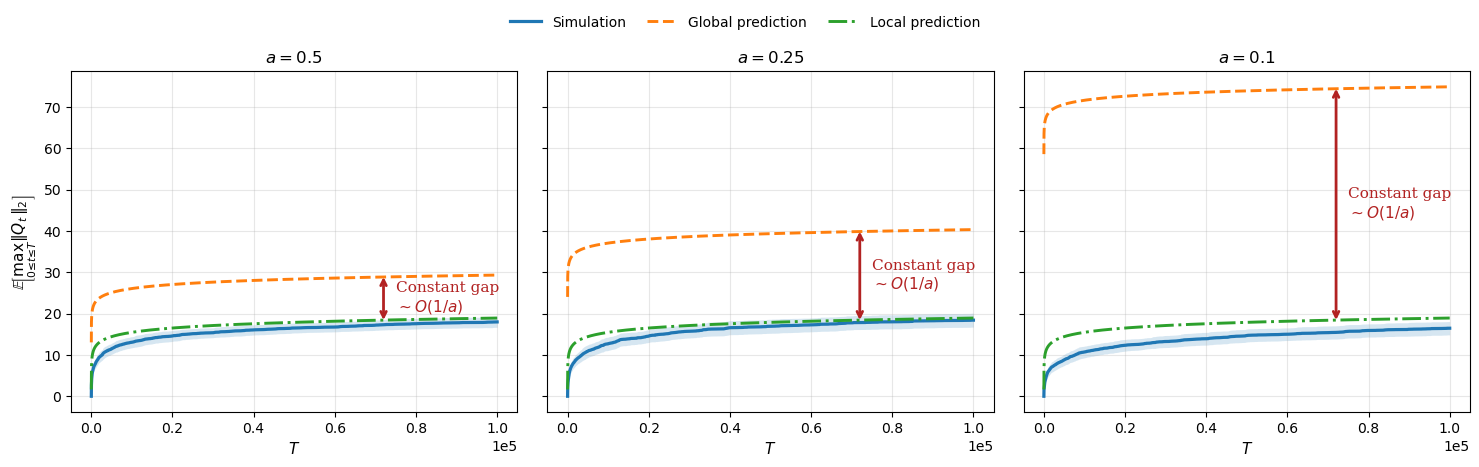

In [7]:

import numpy as np
import matplotlib.pyplot as plt


def simulate_two_queue_maxweight(a=0.1, eps=0.1, T=5000, seed=None):
    """
    Two-queue example:
        S = {(1,0), (0,a)}

    MaxWeight rule:
        choose (1,0) if q1 >= a*q2
        choose (0,a) otherwise

    Arrivals:
        A1 ~ Bernoulli((1-eps)/2)
        A2 ~ Bernoulli(a*(1-eps)/2)

    Then:
        E[A1] + (1/a) E[A2] = 1 - eps

    Returns
    -------
    norm2_path      : ||Q(t)||_2, length T+1
    peak_norm2_path : max_{0<=s<=t} ||Q(s)||_2, length T+1
    """
    rng = np.random.default_rng(seed)

    p1 = 0.5 * (1.0 - eps)
    p2 = 0.5 * a * (1.0 - eps)

    q1 = 0.0
    q2 = 0.0

    norm2_path = np.zeros(T + 1, dtype=float)
    norm2_path[0] = np.sqrt(q1**2 + q2**2)

    for t in range(T):
        if q1 >= a * q2:
            s1, s2 = 1.0, 0.0
        else:
            s1, s2 = 0.0, a

        A1 = rng.binomial(1, p1)
        A2 = rng.binomial(1, p2)

        q1 = max(q1 - min(q1, s1), 0.0) + A1
        q2 = max(q2 - min(q2, s2), 0.0) + A2

        norm2_path[t + 1] = np.sqrt(q1**2 + q2**2)

    peak_norm2_path = np.maximum.accumulate(norm2_path)
    return norm2_path, peak_norm2_path


def estimate_expected_peak_norm2(a=0.1, eps=0.1, T=5000, num_runs=1000, base_seed=0):
    """
    Monte Carlo estimate of E[max_{s<=t} ||Q(s)||_2].

    Returns
    -------
    mean_peak : shape (T+1,)
    std_peak  : shape (T+1,)
    """
    all_peak = np.zeros((num_runs, T + 1), dtype=float)

    for k in range(num_runs):
        _, peak_norm2_path = simulate_two_queue_maxweight(
            a=a,
            eps=eps,
            T=T,
            seed=base_seed + k,
        )
        all_peak[k, :] = peak_norm2_path

    mean_peak = all_peak.mean(axis=0)
    std_peak = all_peak.std(axis=0, ddof=1) if num_runs > 1 else np.zeros(T + 1)
    return mean_peak, std_peak


def global_corollary_bound(t_grid, a=0.1, eps=0.1, prefactor=1.0):
    """
    Global corollary-style expected peak bound:
        E[Peak_t] \lesssim (A_max/eps) log(t+1)
                         + (A_max + S_max)^2 / (eps * alpha_2)
    """
    t_grid = np.asarray(t_grid, dtype=float)

    A_max = np.sqrt(2.0)
    S_max = 1.0
    alpha_2 = a / np.sqrt(1.0 + a**2)

    return prefactor * (
        (A_max / eps) * np.log(t_grid + 1.0)
        + ((A_max + S_max) ** 2) / (eps * alpha_2)
    )


def local_hp_to_expectation_curve(t_grid, eps=0.1, prefactor=1.0):
    """
    Local HP -> expectation-scale curve:
        E[Peak_T] \lesssim 1 + (1/eps)(1 + log(T+1))
    """
    t_grid = np.asarray(t_grid, dtype=float)
    return prefactor * (1.0 + (1.0 / eps) * (1.0 + np.log(t_grid + 1.0)))


def add_gap_annotation(ax, t_grid, global_curve, local_curve, x_frac=0.82):
    gap_color = "#B22222"

    idx = int(x_frac * (len(t_grid) - 1))
    x0 = t_grid[idx]
    y_local = local_curve[idx]
    y_global = global_curve[idx]
    gap = y_global - y_local

    ax.annotate(
        "",
        xy=(x0, y_global),
        xytext=(x0, y_local),
        arrowprops=dict(
            arrowstyle="<->",
            color=gap_color,
            lw=2.0,
            shrinkA=0,
            shrinkB=0,
        ),
    )

    x_text = x0 + 0.03 * t_grid[-1]
    y_text = 0.5 * (y_local + y_global)

    ax.text(
        x_text,
        y_text,
        rf"Constant gap" "\n" rf"$\sim O(1/a)$",
        color=gap_color,
        fontsize=11,
        va="center",
        ha="left",
        fontfamily="serif"
    )


def plot_one_panel(
    ax,
    a=0.1,
    eps=0.1,
    T=5000,
    num_runs=200,
    base_seed=0,
    global_prefactor=1.0,
    local_prefactor=1.0,
    show_std=True,
    std_scale=1.0,
    annotate_gap=True,
    show_ylabel=False,
):
    t_grid = np.arange(T + 1)

    sim_mean, sim_std = estimate_expected_peak_norm2(
        a=a,
        eps=eps,
        T=T,
        num_runs=num_runs,
        base_seed=base_seed,
    )

    global_curve = global_corollary_bound(
        t_grid=t_grid,
        a=a,
        eps=eps,
        prefactor=global_prefactor,
    )

    local_curve = local_hp_to_expectation_curve(
        t_grid=t_grid,
        eps=eps,
        prefactor=local_prefactor,
    )

    if show_std:
        lower = np.maximum(sim_mean - std_scale * sim_std, 0.0)
        upper = sim_mean + std_scale * sim_std
        ax.fill_between(
            t_grid,
            lower,
            upper,
            color="C0",
            alpha=0.18,
            linewidth=0.0,
        )

    sim_line, = ax.plot(
        t_grid,
        sim_mean,
        color="C0",
        linewidth=2.3,
        label="Simulation"
    )
    global_line, = ax.plot(
        t_grid,
        global_curve,
        color="C1",
        linestyle="--",
        linewidth=2.1,
        label="Global prediction"
    )
    local_line, = ax.plot(
        t_grid,
        local_curve,
        color="C2",
        linestyle="-.",
        linewidth=2.1,
        label="Local prediction"
    )

    if annotate_gap:
        add_gap_annotation(ax, t_grid, global_curve, local_curve, x_frac=0.72)

    ax.set_title(fr"$a={a}$", fontsize=12)
    ax.set_xlabel(r"$T$", fontsize=11)
    if show_ylabel:
        ax.set_ylabel(r"$\mathbb{E}\!\left[\max_{0\leq t\leq T}\|Q_t\|_2 \right]$", fontsize=11)

    ax.grid(alpha=0.3)

    ticks = np.linspace(0, T, 6)
    ax.set_xticks(ticks)
    sci_exp = int(np.floor(np.log10(T))) if T > 0 else 0
    ax.ticklabel_format(style="sci", axis="x", scilimits=(sci_exp, sci_exp))

    return sim_line, global_line, local_line


def plot_three_panels_row(
    a_list=(1.0, 0.5, 0.1),
    eps=0.1,
    T=100000,
    num_runs=200,
    base_seed=123,
    global_prefactor=0.1,
    local_prefactor=0.15,
    show_std=True,
    std_scale=0.5,
    annotate_gap=True,
    save_pdf=True,
    pdf_name="three_panel_two_queue.pdf",
):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)

    handles = None
    labels = None

    for j, a in enumerate(a_list):
        sim_line, global_line, local_line = plot_one_panel(
            ax=axes[j],
            a=a,
            eps=eps,
            T=T,
            num_runs=num_runs,
            base_seed=base_seed + 1000 * j,
            global_prefactor=global_prefactor,
            local_prefactor=local_prefactor,
            show_std=show_std,
            std_scale=std_scale,
            annotate_gap=annotate_gap,
            show_ylabel=(j == 0),
        )
        if handles is None:
            handles = [sim_line, global_line, local_line]
            labels = ["Simulation", "Global prediction", "Local prediction"]

    # 顶部统一 legend
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
        handlelength=2.2,
        columnspacing=1.5,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if save_pdf:
        fig.savefig(pdf_name, format="pdf", bbox_inches="tight")
        print(f"Saved figure to {pdf_name}")

    plt.show()


# =========================
# Example run
# =========================
plot_three_panels_row(
    a_list=(0.5, 0.25, 0.1),
    eps=0.1,
    T=100000,
    num_runs=200,
    base_seed=123,
    global_prefactor=0.1,
    local_prefactor=0.15,
    show_std=True,
    std_scale=0.5,
    annotate_gap=True,
    save_pdf=True,
    pdf_name="three_panel_two_queue.pdf",
)